Inicialmente, alla en el 2022, el primer modelo de uso masivo de LLM (CHATGPT Basado en GPT-3.5) tenia una restricción muy particular que se correspondia a la tecnica con la cual se entrenan estos modelos.

Cuando realizabamos una consulta sobre un suceso posterior al 2019 el modelo devolvia un mensaje que indicaba que no tenia datos posteriores a dicha fecha, esto es debido a que el modelo GPT-3.5 habia sido entrenado con un set de datos que llegaba hasta esa fecha, y a partir de alli no tenia mas informacion indexada para poder utilizar.

Modelos posteriores, asi como otros motores como Gemini vinieron a resolver este inconveniente, esto no lo hicieron con un modelo que se volvia a entrenar todos los dias, el modelo era el mismo pero lo que hacia era poder AMPLIAR temporalmente su contexto de datos al realizar un scrapping de internet al momento de la consulta

Si nosotros realizamos una consulta directa a un LLM, sea local o mediante una API y no tiene configurado el acceso a una tool de busqueda en linea, nos sucedera lo mismo que con aquella version de ChatGPT, no tendremos datos actualizados.

Para poder enmendar esta situación podemos valernos de herramientas que realicen el web scrapping y devuelvan el contexto al modelo.

Para este curso vamos a usar **SerpAPI** , elegimos esta API debido a que al momento de redactar el curso, podiamos utilizarla de forma gratuita para las pruebas y practicas.

## ¿Que es SerpAPI?

SerpApi es una interfaz de programación de aplicaciones (API) que permite a los desarrolladores extraer información de las páginas de resultados de motores de búsqueda (SERP) de manera rápida y estructurada.

[https://serpapi.com/](https://serpapi.com/)



----------
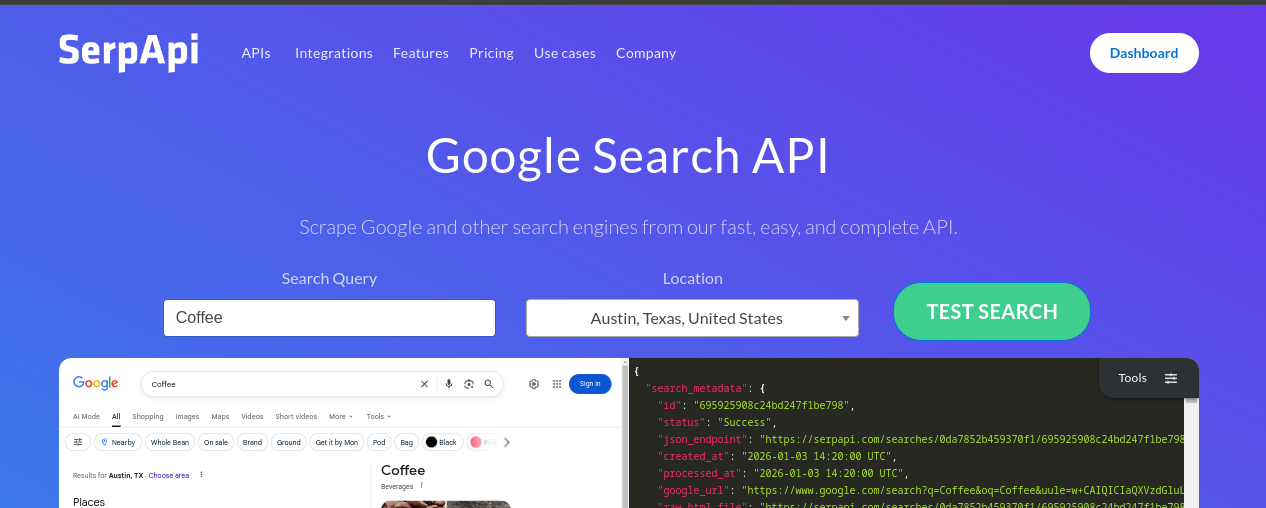


----------------

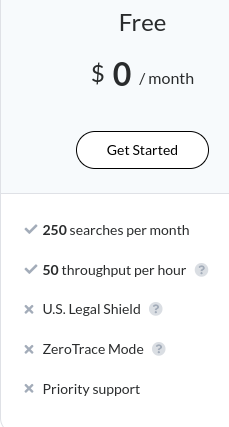

---------------


Antes de avanzar comento algunas otras alternativas que hay disponibles.

Quiero comentar que una de las principales razones por las cuales comence este curso fue por la llamativa costumbre que tenian otros cursos de SOLO usar modelos pagos, API's que lograban resolver todo milagrosamente y que sin dificultad ni tener que hacer un gran troubleshooting lograbas resolver casi cualquier caso simple.

Creo que es preferible aprender conceptualmente y luego tecnicamente el uso de estas herramientas, no como una suite de soluciones/codigo copy/paste sino, como una tecnologia que cambia constantemente. Las API que hoy tenemos disponibles podrian no existir, o tener cambios criticos, en un futuro inmediato y esto nos llevaria a readaptarnos a estos cambios o cambiar completamente de herramienta para solucionar nuestra necesidad.

Comprender de forma clara que necesidad estamos resolviendo con una API, tambien podemos pensarlo como una tool o incluso extensión, nos permite ganar flexibilidad a la hora de readaptarnos a los cambios, asi como tambien poder poder migrar a nuevas soluciones a medida que se van desarrollando y la competencia lleva a mejoras tecnicas o de precio.

Volviendo a lo que veniamos hablando.

>>Principales Alternativas a SerpApi (A Junio 26)

**ScraperAPI**: Excelente para desarrolladores y proyectos a gran escala. Destaca por manejar millones de solicitudes mensuales sin bloquearse, rotar proxies automáticamente y resolver captchas.

**Serper (serper.dev)**: La opción preferida para proyectos de Inteligencia Artificial (LLMs) y agentes. Es muy rápida, ligera y está optimizada principalmente para extraer resultados de texto puro, ubicaciones y respuestas orgánicas.DataForSEO: Diseñada específicamente para agencias de marketing y SEO. Ofrece métricas avanzadas (costo por clic, volumen de búsqueda histórico, posición de palabras clave).

**Bright Data**: Conocida por tener la red de proxies residenciales más grande y estable. Es ideal si requieres geolocalización ultraprecisa y una gran cantidad de puntos de datos extraídos al mismo tiempo.




## ¿Que es SERP?

Empecemos el dia por el desayuno, cuando realizamos una busqueda en internet con una app de buscador clasico como Google o Bing obtenemos como respuesta (en terminos generales) un:
SERP son las siglas en inglés de Search Engine Results Page, que se traduce como Página de Resultados del Motor de Búsqueda. Es simplemente la pantalla que devuelve un buscador justo después de que escribis una consulta o palabra clave.

Normalmente contiene una lista de páginas web, imágenes, vídeos y otros tipos de contenido que el motor de búsqueda considera relevantes para la consulta del usuario, o (dependiendo el motor y algoritmo usado al momento de la consulta) tiene predefinido mostrar al usuario para el contexto de la consulta.

Los resultados de búsqueda (SERP) son dinámicos y pueden variar en función muchos factores:

- El motor de busqueda consultado
- La versión del algoritmo al momento de la consulta
- Las principales busquedas similares ejecutadas por otros usuarios
- El formato de la busqueda utilizada
- La geolocalización del usuario
- Historial de búsqueda y preferencias
- Perfil completo del usuario, sea mediante cache o usuario logeado
- Dispositivo (PC, móvil, etc.)


Es decir que es altamente probable que dos usuarios realicen la misma busqueda y el SERP obtenido sea distinto, incluso un mismo usuario puede repetir la misma busqueda en distintos momentos y el resultado tambien tendra cambios.


Tomando como ejemplo la busqueda en Google al día de hoy el formato o anatomia de una respuesta de SERP encontramos:

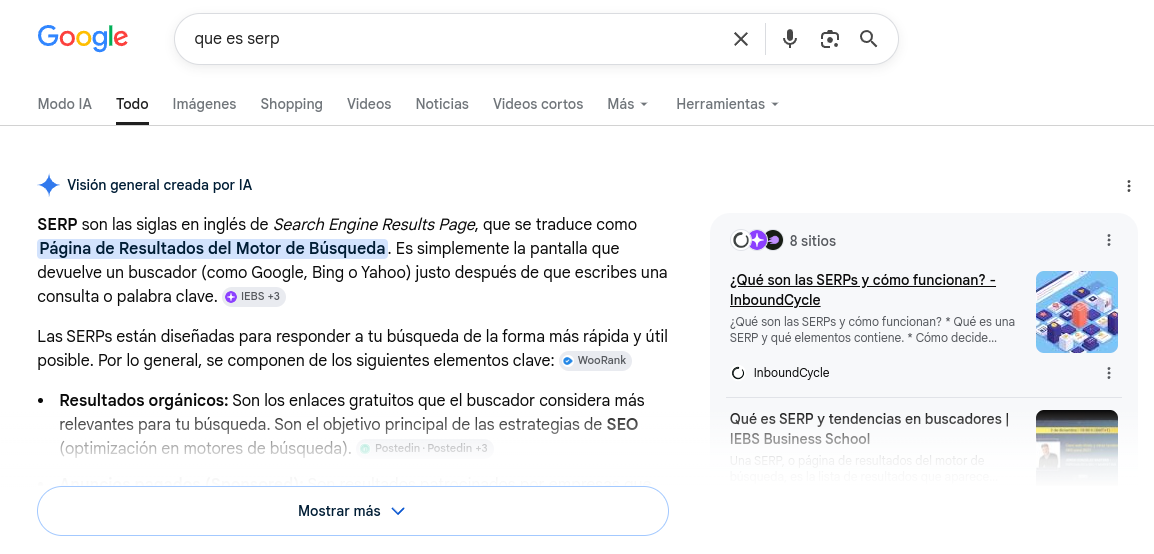
-------
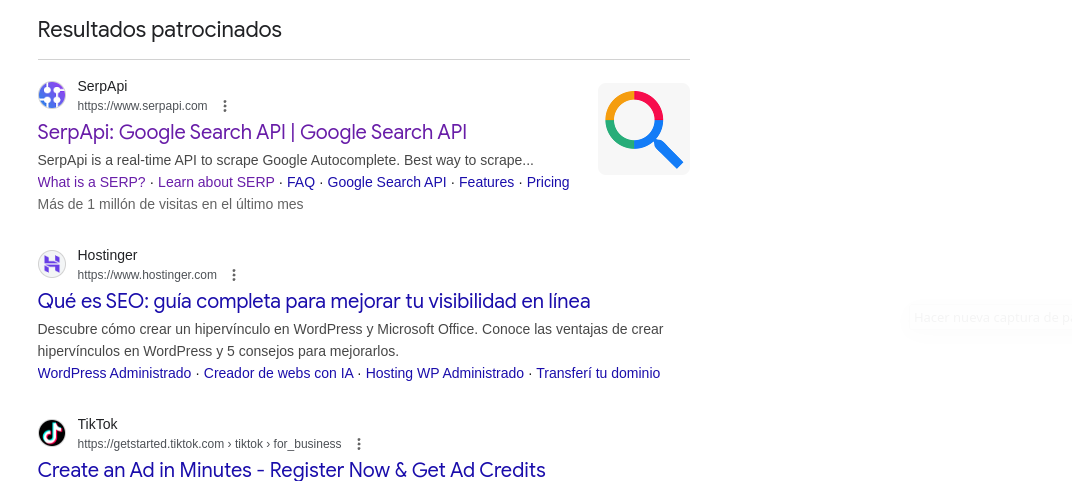
------
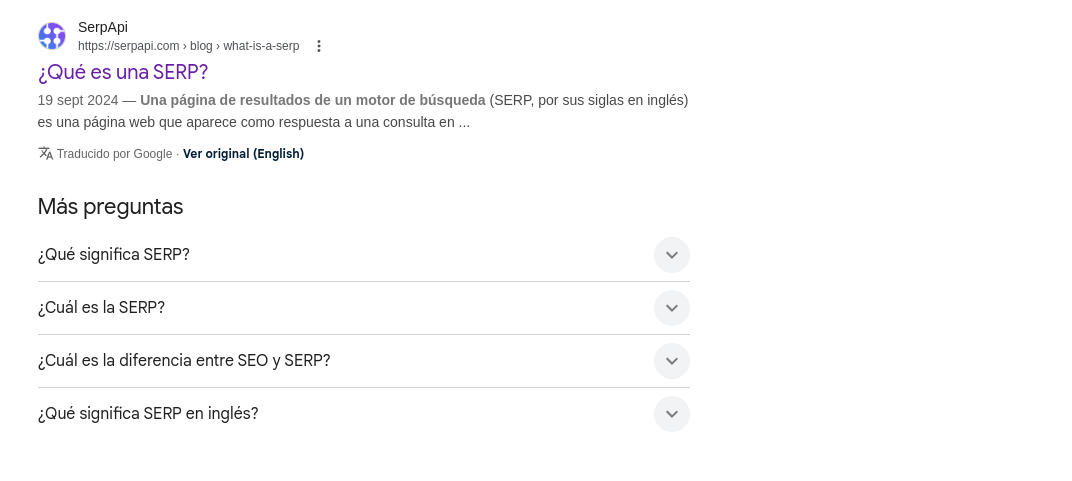



En las imagenes podemos destacar en una primer instancia varias secciones que conforman al día de hoy los resultados de busqueda, es decir el SERP de Google.
Incluso es llamativo ver como los resultados organicos, es decir el listado de URL que mejor match hacen con nuestra pregunta recien aparecen luego de varias secciones.

La estructura actual tambien tiene cambios segun tipo de consulta realizada, puedes aparecer nuevos recuadros de datos geolocalizados con mapas, resultados de APIs como por ejemplo de clima o financieras.




## ¿Como funcionan por debajo estas API?

Si bien estas API nos devuelven todo resuelto, podemos producir nuestro propio sistema de scrapping, sea para no depender de APIS externas o para poder aprender como funcionan.

Para hacer un sistema basico podemos usar la libreria **googlesearch-python**


Vamos a probar un codigo simple pero funcional:

Primero instalamos la libreria
!pip install ddgs

Esta libreria permite un scrapping con duckduckgo (un motor como podria ser Google o Bing), utilice esta libreria debido a que las versiones de librerias libres que trabajan con Google esta teniendo (al día de hoy) un bloqueo en las consultas y no devuelven resultados.

Luego usamos el siguiente codigo

--------


```
# Se van a ignorar Warnings  asociados a las versiones en uso
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=ResourceWarning)


# El scrapping se ejecuta en 3 etapas
# 1) Realizamos la busqueda mediante ddgs
# 2) Descargamos los datos en memoria mediante requests
# 3) Formateamos el HTML con BeautifulSoup para extraer los datos especificos
import requests
from bs4 import BeautifulSoup
from ddgs import DDGS



def buscador(query:str)->str:
  """
  Función para realizar una busqueda en internet y extraer el resultado.
  in:
    query: str
  out:
    url: str
    title: str
    text: str
  """

  # Definimos el header que va a recibir como meta dato el motor de busqueda
  headers = {"User-Agent": "Mozilla/5.0"}

  # Corremos el metodo de duckduckgo para la busqueda en internet
  with DDGS() as ddgs:
      results = list(ddgs.text(query, max_results=1))

  # Extraemos la url de la busqueda
  r = results[0]
  url = r["href"]

  # Con la URL resultado de la busqueda, descargamos el html con request y lo formateamos con BeautifulSoup
  response = requests.get(url, headers=headers)
  soup = BeautifulSoup(response.text, "html.parser")

  for tag in soup(["script", "style"]):
      tag.decompose()

  # Extraemos el titulo y el texto
  title = soup.title.string if soup.title else ""
  text = " ".join(soup.get_text().split())

  return (url, title, text)
```
--------------

Se puede probar el codigo directamente desde Colab o descargando en local

[01_Ejecucion_de_codigo_busqueda_en_internet](https://colab.research.google.com/drive/1wfm-TSt4e3bn5gkAKLXR8gDlCHndgq_C?usp=sharing)


Este codigo nos puede servir como una herramienta para brindarle al LLM un contexto actualizado sobre el cual trabajar, esto lo logramos al pasarle como parte del prompt la información obtenida con la consulta anterior.


Podemos ampliar este tema ya sea usando IA o con paginas como:

https://roundproxies.com/blog/how-to-use-googlesearch/

https://roundproxies.com/blog/scrape-google-search-results/

## Prueba de LLM con web scrapping

Ahora vamos a unir dos partes de codigo que ya vimos:

1) Busqueda en la web de información

2) Consulta a un LLM

El punto de union entre estas dos partes va a ser el prompt.

De esta forma ampliamos la base de conocimiento del LLM para poder responder

Podemos ver y ejecutar el codigo desde

[01_Ejemplo_codigo_LLM_con_web_scrapper_propio](https://colab.research.google.com/drive/1CPz3aXkUTA983j5jSIqgNvACuoNWMILn?usp=sharing)

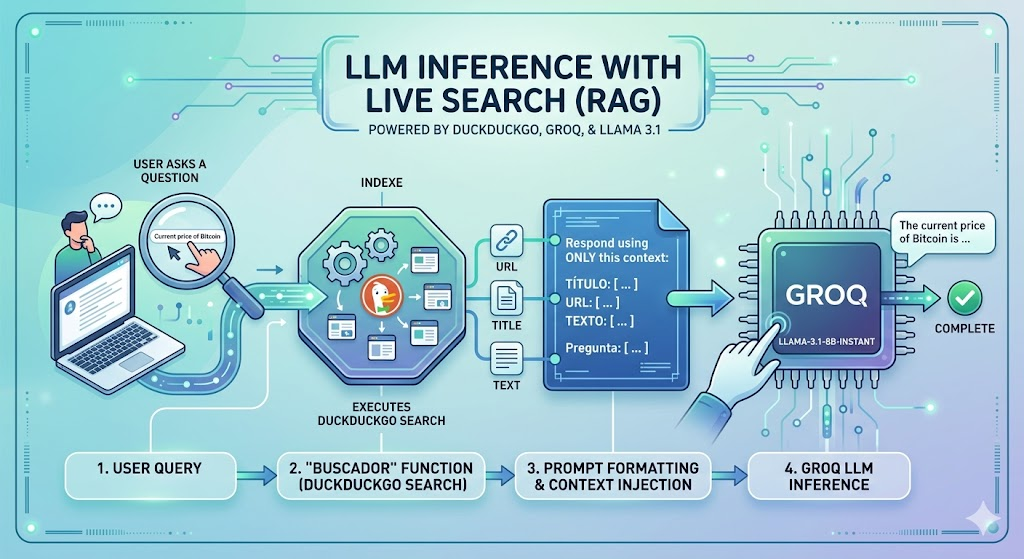

## Prueba de LLM con SERPAPI

Se puede ver y ejecutar el codigo completo desde:

[01_Ejemplo_codigo_busqueda_internet_SERPAPI](https://colab.research.google.com/drive/1GQR3uuPw_kfzmW5Gq_2RzVDp4SulVC6N?usp=sharing)

La arquitectura es muy similar a la anterior, incluso vamos a reciclar la sección de codigo que realiza la llamada al modelo llama desde Groq. Lo que vamos a cambiar es la etapa del BUSCADOR, en donde ahora vamos a valernos de una api externa que es mas robusta y presenta los resultados de una forma mas eficiente y ordenada.


De esta forma el gran cambio que tenemos es:



```
# El scrapping se ejecuta en 2 etapas
# 1) Pasamos la busqueda a la web https://serpapi.com/search
# 2) Descargamos los datos en memoria mediante requests

import requests

def buscador_con_serpapi(query:str)->str:
  """
  Función para realizar una busqueda en internet y extraer el resultado.
  in:
    query: str
  out:
    url: str
    title: str
    text: str
  """

  #URL de la pagina serpapi adonde vamos a enviar la consulta
  url = "https://serpapi.com/search"

  # Parametros necesarios: cual es la query, apikey que generamos en la pagina de serpapi, y el motor de consulta que debera usar  
  params = {
        "q": query,
        "api_key": SERAPI,
        "engine": "google"
  }

  # Descargamos la información generada por la pagina serpapi
  response = requests.get(url, params=params)
  data = response.json()


  # La información devuelta tendra formato JSON y se debera consultar en la documentación de SERPAPI cuales son los key disponibles
  r = data["organic_results"][0]

  # Tomamos los valores de titulo,link y texto/cuerpo para el primer resultado del tipo ORGANICO
  title = r["title"]
  link = r["link"]
  text = r.get("snippet", "")

  return (url, title, text)

```





----------------

>Si te quedan preguntas no dudes en contactarme

>>>arielmeragelman@gmail.com

>>>Lic. Sebastian A. Meragelman